In [1]:
%matplotlib widget
%load_ext autoreload
%autoreload 2

import torch
import numpy as np
import gsplat
import matplotlib.pyplot as plt

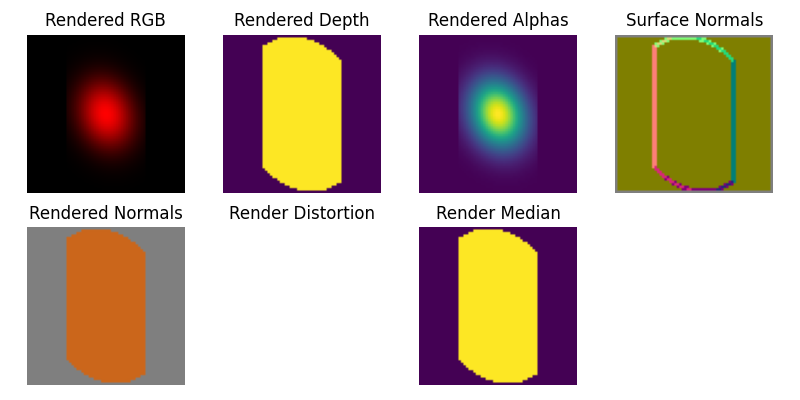

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)
C = 1
N = 1
means = torch.zeros(N, 3, device=device)
means[..., 2] = 1
quats = torch.randn(N, 4, device=device)
quats = quats / (quats.norm(dim=-1, keepdim=True) + 1e-6)
scales = torch.zeros(N, 3, device=device)
scales[..., :2] = 0.3
opacities = torch.ones(N, device=device)
colors = torch.zeros(N, 3, device=device)
colors[..., 0] = 1.0

A33 = torch.eye(3)
b31 = torch.zeros(3, device=device)
# A33 = torch.tensor([[1.2, 0.0, 0.1],
#                     [-0.05, 0.9, -0.1],
#                     [0.0, 0.1, 1.1]], device=device)  # identity rotation matrix
# b31 = torch.tensor([-0.2, 0.1, 0.0], device=device)  # translation vector
viewmats = torch.zeros((C, 4, 4), device=device)
viewmats[..., :3, :3] = A33.unsqueeze(0).expand(C, 3, 3)
viewmats[..., :3, 3] = b31.unsqueeze(0).expand(C, 3)
viewmats[..., 3, 3] = 1.0
# W, H = 24, 20
W, H = 64, 64
fx, fy, cx, cy = W//2, H//2, W // 2, H // 2
Ks = torch.broadcast_to(
    torch.tensor([[fx, 0.0, cx], [0.0, fy, cy], [0.0, 0.0, 1.0]], device=device),
    (C, 3, 3),
)
with torch.no_grad():
    rendered_pkg, rendered_alphas, rendered_normals, surf_normals, render_distort, render_median, info = gsplat.rasterization_2dgs(
        means=means,
        quats=quats,
        scales=scales,
        opacities=opacities,
        colors=colors,
        viewmats=viewmats,
        Ks=Ks,
        width=W,
        height=H,
        packed=False,
        render_mode='RGB+ED',
        distloss=False,
        camera_model='ortho',
        # depth_mode="median",
        planar_depth=False,
    )

    rendered_pkg = rendered_pkg.cpu()
    rendered_alphas = rendered_alphas.cpu()
    rendered_normals = rendered_normals.cpu()
    surf_normals = surf_normals.cpu()
    render_distort = render_distort.cpu()
    render_median = render_median.cpu()

fig, ax = plt.subplots(2, 4, figsize=(8, 4))
axf = ax.flatten()
for a in axf:
    a.axis("off")
axf[0].imshow(rendered_pkg[0, ..., :3])
axf[0].set_title("Rendered RGB")
axf[1].imshow(rendered_pkg[0, ..., -1])
axf[1].set_title("Rendered Depth")
axf[2].imshow(rendered_alphas[0, ..., 0])
axf[2].set_title("Rendered Alphas")
axf[3].imshow(surf_normals*0.5+0.5)
axf[3].set_title("Surface Normals")

rendered_normals /= (rendered_normals.norm(dim=-1, keepdim=True) + 1e-6)
axf[4].imshow(rendered_normals[0] * 0.5 + 0.5)
axf[4].set_title("Rendered Normals")
# axf[5].imshow(render_distort[0, ..., 0])
axf[5].set_title("Render Distortion")
axf[6].imshow(render_median[0, ..., 0])
axf[6].set_title("Render Median")

fig.tight_layout()



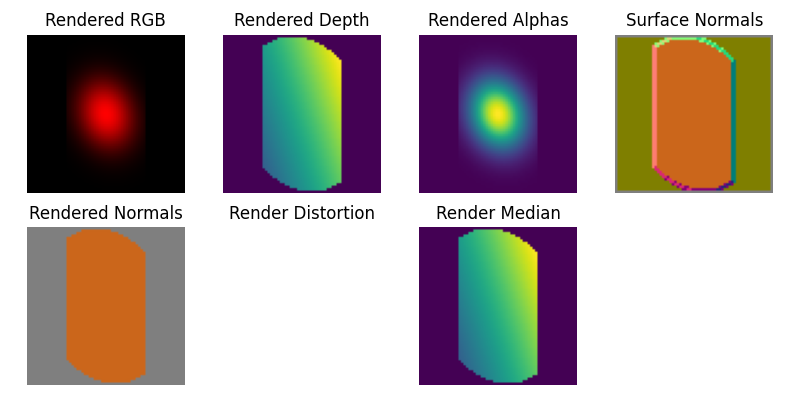

In [ ]:

with torch.no_grad():
    rendered_pkg, rendered_alphas, rendered_normals, surf_normals, render_distort, render_median, info = gsplat.rasterization_2dgs(
        means=means,
        quats=quats,
        scales=scales,
        opacities=opacities,
        colors=colors,
        viewmats=viewmats,
        Ks=Ks,
        width=W,
        height=H,
        packed=False,
        render_mode='RGB+ED',
        distloss=False,
        camera_model='ortho',
        # depth_mode="median",
        planar_depth=True
    )

    rendered_pkg = rendered_pkg.cpu()
    rendered_alphas = rendered_alphas.cpu()
    rendered_normals = rendered_normals.cpu()
    surf_normals = surf_normals.cpu()
    render_distort = render_distort.cpu()
    render_median = render_median.cpu()

fig, ax = plt.subplots(2, 4, figsize=(8, 4))
axf = ax.flatten()
for a in axf:
    a.axis("off")
axf[0].imshow(rendered_pkg[0, ..., :3])
axf[0].set_title("Rendered RGB")
axf[1].imshow(rendered_pkg[0, ..., -1])
axf[1].set_title("Rendered Depth")
axf[2].imshow(rendered_alphas[0, ..., 0])
axf[2].set_title("Rendered Alphas")
axf[3].imshow(surf_normals*0.5+0.5)
axf[3].set_title("Surface Normals")

rendered_normals /= (rendered_normals.norm(dim=-1, keepdim=True) + 1e-6)
axf[4].imshow(rendered_normals[0] * 0.5 + 0.5)
axf[4].set_title("Rendered Normals")
# axf[5].imshow(render_distort[0, ..., 0])
axf[5].set_title("Render Distortion")
axf[6].imshow(render_median[0, ..., 0])
axf[6].set_title("Render Median")

fig.tight_layout()